In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import numpy as np
import joblib


In [11]:
model_path = '/export2/obasit/ClusterLevelServing/vllm_profiler_logs/latency_model/'

est_tp2_tp4 = joblib.load(model_path + "lightgbm_tp2_tp4/unified_latency_model_tp2_tp4.joblib")['model']
est_tp8 = joblib.load(model_path + "lightgbm_tp8/unified_latency_model_tp8.joblib")['model']

def infer(model, tp, freq, tokens_prefill=None, tokens_decode=None):
    FEATURE_COLS = [
        'prefill_batch_size', 'prefill_input_len_sum', 'prefill_input_len_mean', 'prefill_input_len_std',
        'decode_batch_size', 'decode_input_len_sum', 'decode_input_len_mean', 'decode_input_len_std',
        'tp_degree', 'freq_mhz'
    ]

    X = pd.DataFrame([{
        "prefill_batch_size": np.log1p(len(tokens_prefill) if tokens_prefill else 0),
        "prefill_input_len_sum": np.log1p(sum(tokens_prefill) if tokens_prefill else 0),
        "prefill_input_len_mean": np.log1p(float(np.mean(tokens_prefill))) if tokens_prefill else 0,
        "prefill_input_len_std": np.log1p(float(np.std(tokens_prefill)) if tokens_prefill else 0),
        "decode_batch_size": np.log1p(len(tokens_decode) if tokens_decode else 0),
        "decode_input_len_sum": np.log1p(sum(tokens_decode) if tokens_decode else 0),
        "decode_input_len_mean": np.log1p(float(np.mean(tokens_decode))) if tokens_decode else 0,
        "decode_input_len_std": np.log1p(float(np.std(tokens_decode)) if tokens_decode else 0),
        "tp_degree": tp,
        "freq_mhz": np.log1p(freq),
    }], columns=FEATURE_COLS)

    # otherwise assume sklearn pipeline
    pred = np.exp(model.predict(X, device_type='cpu', njobs=1))
    return float(pred[0])

# Prefill

## TP2

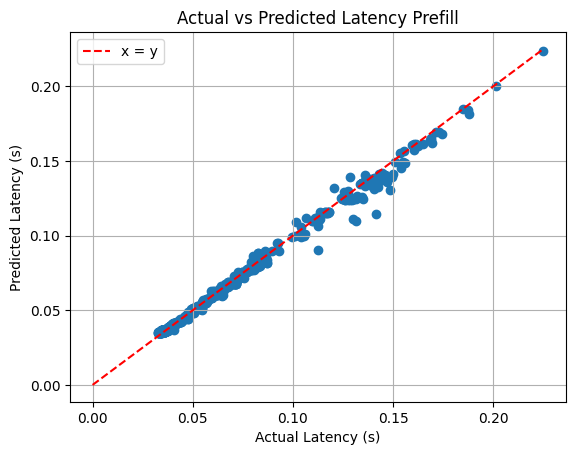

In [13]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps4_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/prefill_0_Oct13031340/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=tokens, tp=2, freq=1080) for tokens in token_lists]

plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')
plt.legend()
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

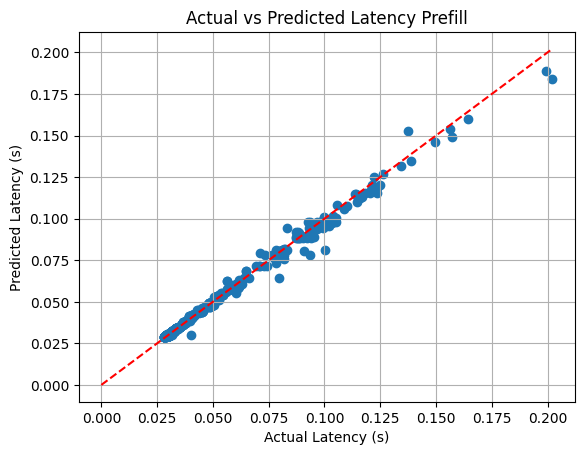

In [14]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp2_logs_num1k/profiler_logs_seed1k_rps8_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP2Prefill_1xTP2/default_log_path/prefill_0_Oct13022453/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=tokens, tp=2, freq=1830) for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')
plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

## TP4

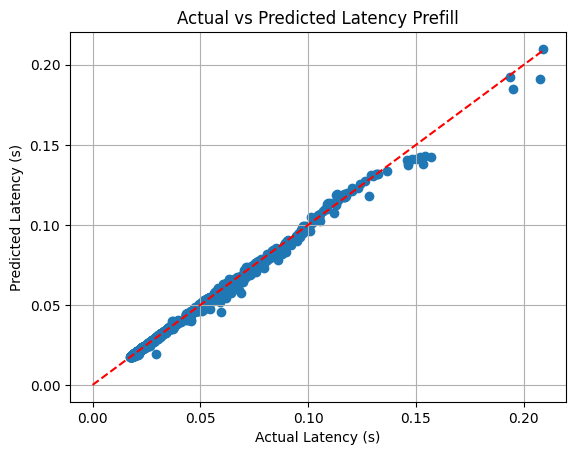

In [15]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps30_freq1980/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13034118/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=tokens, tp=4, freq=1830) for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

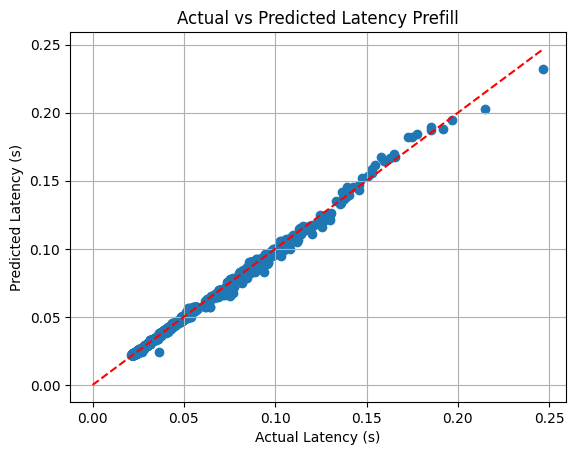

In [16]:
path = "/export1/liu3882/llm_energy/DistServe/my_script/eval_results_Oct12/tp4_logs_num4k/profiler_logs_seed1k_rps15_freq1080/meta-llama/Llama-3.3-70B-Instruct/H100/1xTP4Prefill_1xTP4/default_log_path/prefill_0_Oct13041652/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)

token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=tokens, tp=4, freq=1080) for tokens in token_lists]
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency Prefill")
plt.grid(True)
plt.show()

## TP8

# Decode

## TP2

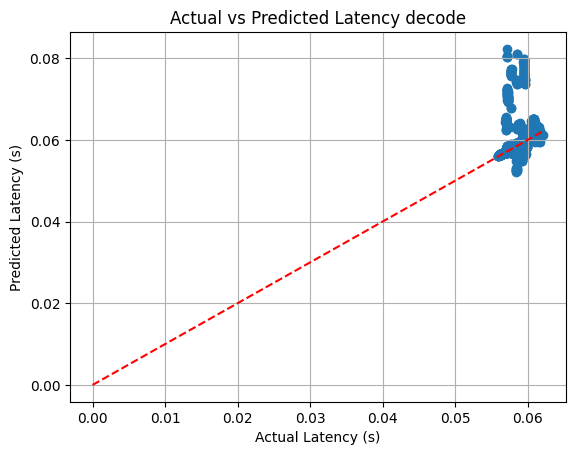

In [17]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_360_1RPS/engine_0.csv"
tp=2
freq=360
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
        row.token_budget_used != len(row.num_prompt_tokens_reqs_evald):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

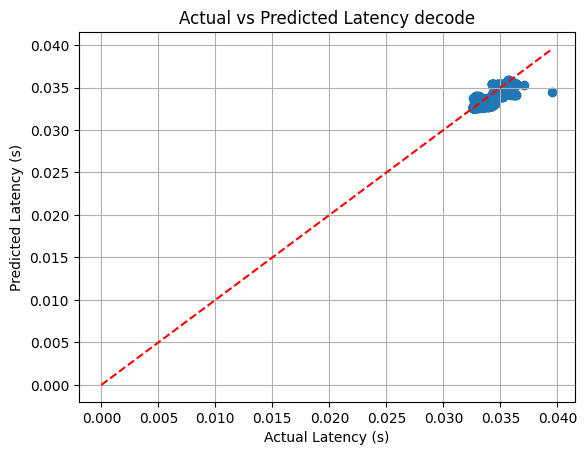

In [18]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_1080_2RPS/engine_0.csv"
tp=2
freq=1080
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
        row.token_budget_used != len(row.num_prompt_tokens_reqs_evald):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

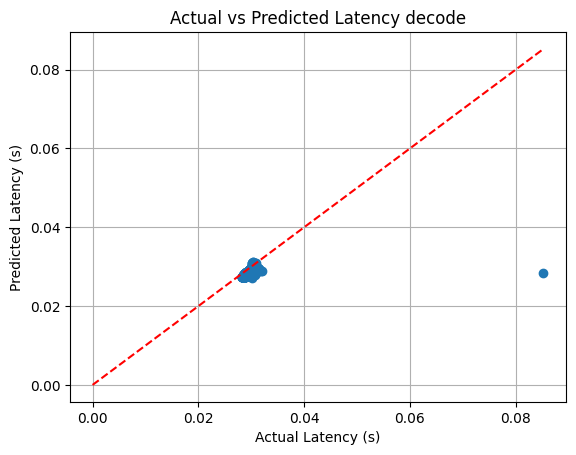

In [19]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_1830_3RPS/engine_0.csv"
tp=2
freq=1830
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
        row.token_budget_used != len(row.num_prompt_tokens_reqs_evald):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

## TP4

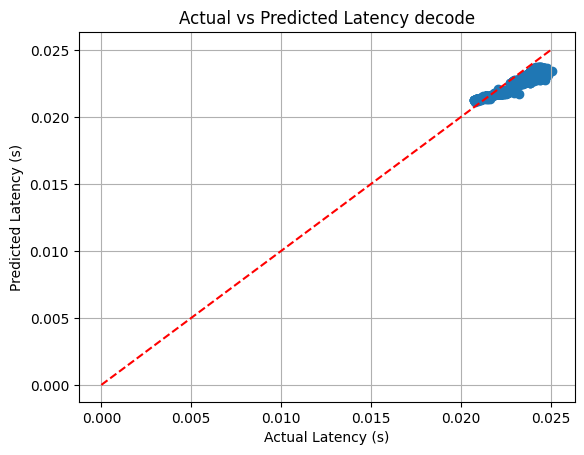

In [20]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP4_1080_7RPS/engine_0.csv"
tp=4
freq=1080
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
        row.token_budget_used != len(row.num_prompt_tokens_reqs_evald):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()


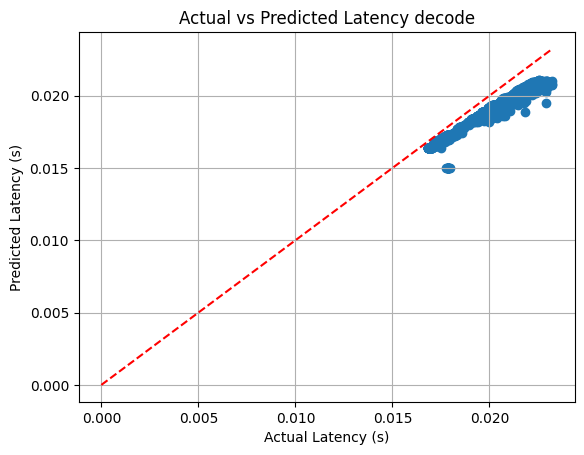

In [21]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP4_1830_15RPS/engine_0.csv"
tp=4
freq=1830
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
        row.token_budget_used != len(row.num_prompt_tokens_reqs_evald):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



## TP8


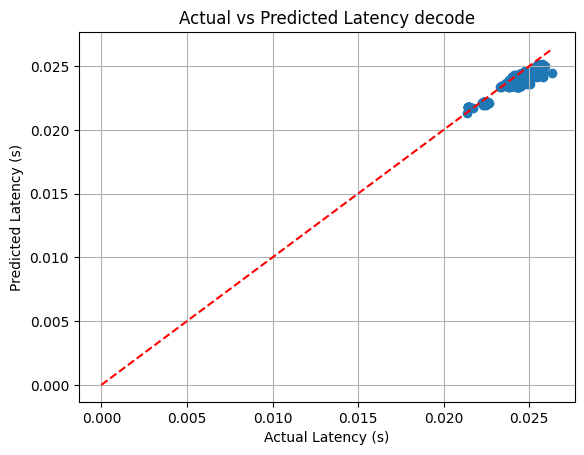

In [4]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_780_7RPS/engine_0.csv"
tp=8
freq=780
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
        row.token_budget_used != len(row.num_prompt_tokens_reqs_evald):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp8, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()



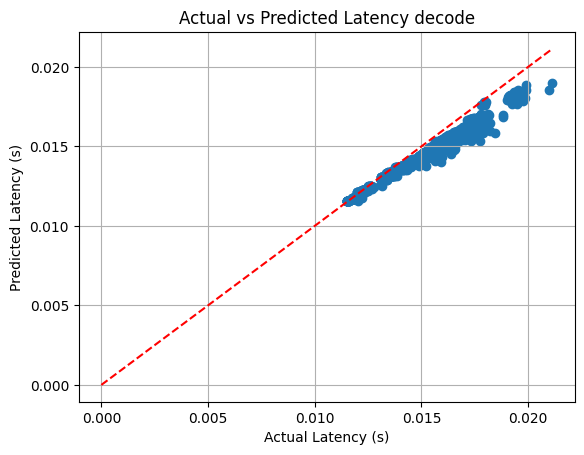

In [5]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_1830_25RPS/engine_0.csv"
tp=8
freq=1830
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
        row.token_budget_used != len(row.num_prompt_tokens_reqs_evald):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp8, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

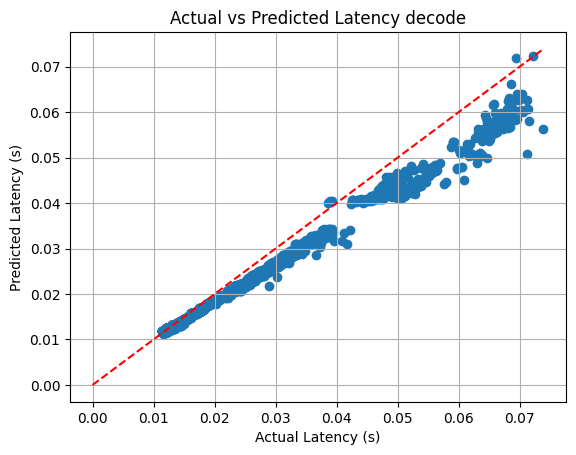

In [6]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_1830_45/engine_0.csv"
tp=8
freq=1830
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs or \
        row.token_budget_used != len(row.num_prompt_tokens_reqs_evald):
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) == 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp8, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency decode")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

# Mixed

## TP2

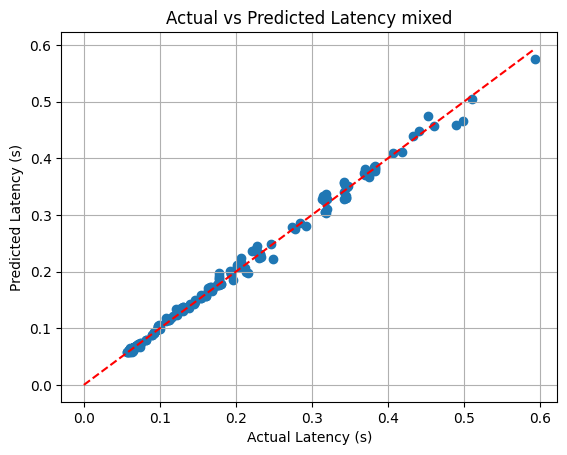

In [22]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_360_1RPS/engine_0.csv"
tp=2
freq=360
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) > 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

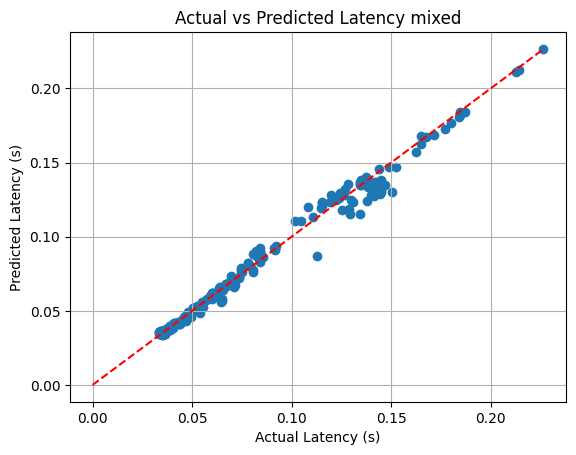

In [23]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_1080_2RPS/engine_0.csv"
tp=2
freq=1080
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) > 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

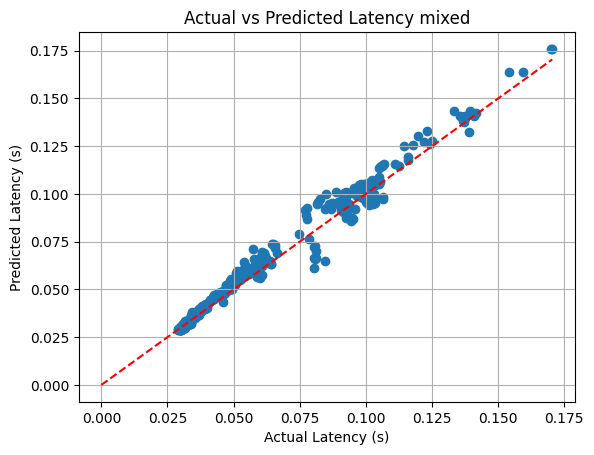

In [24]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP2_1830_3RPS/engine_0.csv"
tp=2
freq=1830
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) > 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

## TP4

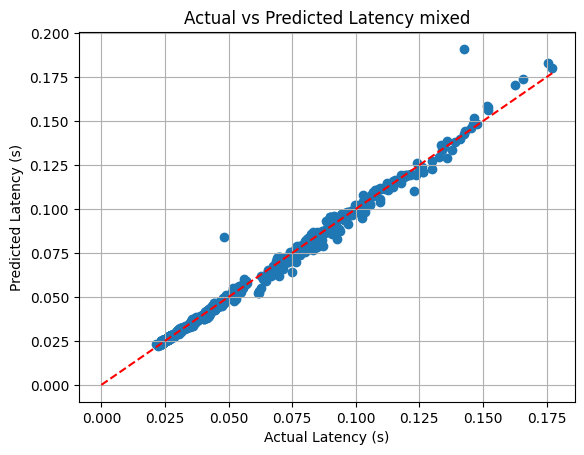

In [25]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP4_1080_7RPS/engine_0.csv"
tp=4
freq=1080
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) > 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()


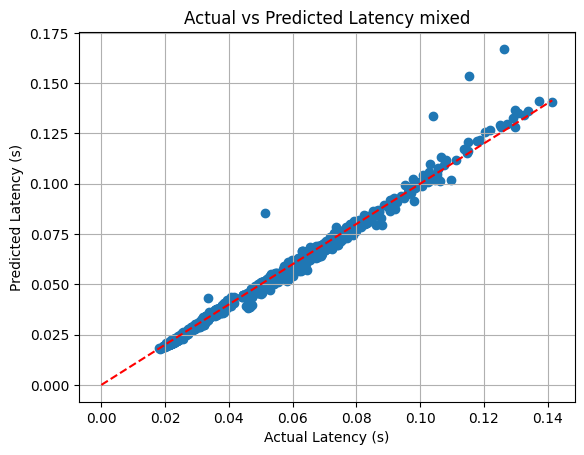

In [26]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP4_1830_15RPS/engine_0.csv"
tp=4
freq=1830
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) > 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp2_tp4, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()


## TP8

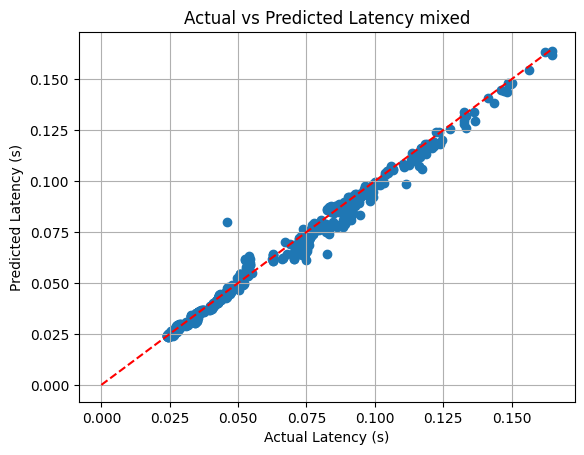

In [7]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_780_7RPS/engine_0.csv"
tp=8
freq=780
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) > 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp8, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()


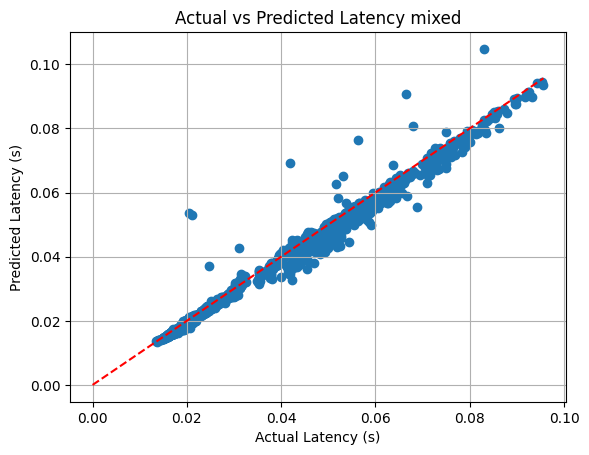

In [ ]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_1830_25RPS/engine_0.csv"
tp=8
freq=1830
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) > 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp8, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]


plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()


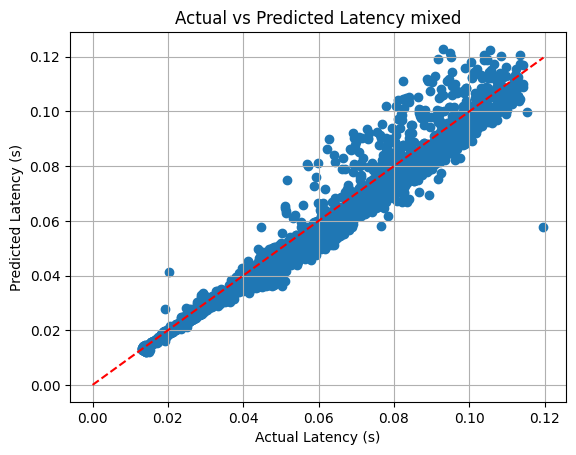

In [9]:
path = "/export2/obasit/ClusterLevelServing/vllm_profiler_logs/validation_runs/TP8_1830_45/engine_0.csv"
tp=8
freq=1830
df_decode = pd.read_csv(path)


df_decode['inter_token_latencies_iter_evald'] = df_decode['inter_token_latencies_iter'].apply(eval)
df_decode['iter_lat'] = df_decode['inter_token_latencies_iter_evald'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)
df_decode['num_prompt_tokens_reqs_evald'] = df_decode['num_prompt_tokens_reqs'].apply(eval)
df_decode['max_num_generation_tokens_iter_evald'] = df_decode['max_num_generation_tokens_iter'].apply(eval)

prefill_token_lists = []
decode_token_lists = []
latency_lists = []
for row in df_decode.itertuples():
    if len(row.num_prompt_tokens_reqs_evald) == 0 or \
        len(row.max_num_generation_tokens_iter_evald) == 0 or \
        len(row.num_prompt_tokens_reqs_evald) != len(row.max_num_generation_tokens_iter_evald) or \
        pd.isna(row.iter_lat) or \
        len(row.num_prompt_tokens_reqs_evald) != row.num_running_reqs:
        continue
    else:
        prefill_lens = []
        decode_lens = []
        
        for i, (prompt_len, gen_tok) in enumerate(zip(row.num_prompt_tokens_reqs_evald, row.max_num_generation_tokens_iter_evald)):
            if gen_tok == 1:
                # This is a prefill request
                prefill_lens.append(prompt_len)
            else:
                # This is a decode request
                # Total KV cache size = prompt_len + gen_tokens
                decode_lens.append(prompt_len + gen_tok)
        if len(prefill_lens) > 0 and len(decode_lens) > 0:
            prefill_token_lists.append(prefill_lens)
            decode_token_lists.append(decode_lens)
            latency_lists.append(row.iter_lat)

predicted_latencies = [infer(est_tp8, tokens_prefill=prefill_tokens, tokens_decode=decode_tokens, tp=tp, freq=freq) for prefill_tokens, decode_tokens in zip(prefill_token_lists, decode_token_lists)]
plt.scatter(latency_lists, predicted_latencies)
plt.plot([0, max(latency_lists)], [0, max(latency_lists)], color='red', linestyle='--', label='x = y')

plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency mixed")
plt.grid(True)
# plt.xlim(0, 0.05)
# plt.ylim(0, 0.05)
plt.show()

In [31]:
# df_decode['predicted_iter_lat'] = np.nan
# for pred, real in zip(predicted_latencies, latency_lists):
#     df_decode.loc[df_decode['iter_lat'] == real, 'predicted_iter_lat'] = pred
# df_decode['abs_error'] = abs(df_decode['predicted_iter_lat'] - df_decode['iter_lat'])
# df_decode.dropna().to_csv("check.csv")